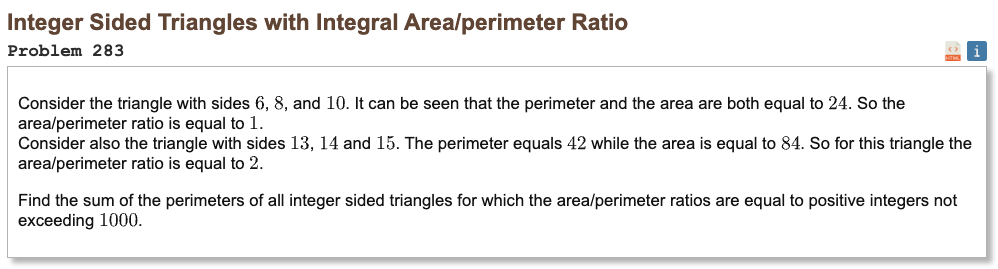

## Initial approach

* notice that the area to perimeter condition is really just telling us the inradius must be an even integer, so we only need to check inradii up to 2000
* rewrite every triangle using the three tangent length pieces around the incircle, because then the side lengths and the perimeter become much easier to control
* after that rewrite, the search turns into finding positive integer triples with a clean divisibility relation, instead of scanning all side length combinations
* sort those three helper values from small to large so each triangle is counted only once
* a key bound shows the product of the two smaller helper values stays within a small multiple of the inradius square, which makes the search finite and practical
* the main speed trick is to stop looping over the middle value directly and instead enumerate a short divisor list that determines it indirectly
* use array to keep the smallest prime factor sieve compact and fast while factoring many numbers repeatedly

In [1]:
from math import isqrt, sqrt
from array import array

def compute_spf(limit):
    spf = array("I", [0]) * (limit + 1)
    if limit >= 1:
        spf[1] = 1
    for i in range(2, limit + 1, 2):
        spf[i] = 2
    for i in range(3, limit + 1, 2):
        if spf[i] == 0:
            spf[i] = i
            ii = i * i
            if ii <= limit:
                step = i << 1
                for j in range(ii, limit + 1, step):
                    if spf[j] == 0:
                        spf[j] = i
    return spf

def factorize_list(num, spf):
    out = []
    while num > 1:
        p = spf[num]
        cnt = 1
        num //= p
        while num > 1 and spf[num] == p:
            cnt += 1
            num //= p
        out.append((p, cnt))
    return out

def merge_factor_lists(a, b):
    i = 0
    j = 0
    out = []
    while i < len(a) and j < len(b):
        pa, ea = a[i]
        pb, eb = b[j]
        if pa == pb:
            out.append((pa, ea + eb))
            i += 1
            j += 1
        elif pa < pb:
            out.append((pa, ea))
            i += 1
        else:
            out.append((pb, eb))
            j += 1
    if i < len(a):
        out.extend(a[i:])
    if j < len(b):
        out.extend(b[j:])
    return out

def divisors_limited(factors, limit):
    divs = [1]
    for p, e in factors:
        new = []
        for d in divs:
            v = d
            for _ in range(e + 1):
                if v > limit:
                    break
                new.append(v)
                v *= p
        divs = new
    return divs

In [2]:
def solve(limit_k=1000):
    max_r = 2 * limit_k
    max_n = max_r * max_r
    max_x = isqrt(3 * max_n)
    max_m = max_n + max_x * max_x
    spf = compute_spf(max_m)
    squares = [i * i for i in range(max_x + 1)]
    total = 0
    sqrt3 = sqrt(3.0)

    for r in range(2, max_r + 1, 2):
        n = r * r
        fn = factorize_list(n, spf)
        max_x_r = int(r * sqrt3)
        limit_d = 2 * n

        for x in range(1, max_x_r + 1):
            m = squares[x] + n
            fm = factorize_list(m, spf)
            merged = merge_factor_lists(fn, fm)

            for d in divisors_limited(merged, limit_d):
                nd = n + d
                if nd % x != 0:
                    continue
                y = nd // x
                if y < x:
                    continue
                num = n * (x + y)
                if num % d != 0:
                    continue
                z = num // d
                if z < y:
                    continue
                total += 2 * (x + y + z)

    return total

In [3]:
%%time
result = solve()
print("Result:", result)

Result: 28038042525570324
CPU times: user 58.4 s, sys: 153 ms, total: 58.6 s
Wall time: 58.8 s
